# Notebook 02 - Estimation dari Data Member A

---
### AI Disclosure

**Member:** Amila Zahira — Estimation Analyst | **Tools used:** Claude

| Tugas | Alat | Prompt (Ringkasan) | Pemanfaatan Output |
|------|------|-------------------|---------------------|
| Pembuatan visualisasi likelihood dan posterior | Claude | "Generate matplotlib likelihood and posterior visualization" | Digunakan sebagai referensi visualisasi untuk notebook estimasi |

**Written entirely without AI:** Sel Interpretasi

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist

sys.path.append(os.path.abspath('..'))

from src.estimator import (
    mle_bernoulli,
    mle_poisson,
    beta_posterior,
    log_likelihood_bernoulli,
    log_likelihood_poisson,
)

In [2]:
project_root = Path.cwd()
if not (project_root / 'data' / 'clean').exists() and (project_root.parent / 'data' / 'clean').exists():
    project_root = project_root.parent

issues_path = project_root / 'data' / 'clean' / 'dataset_issues_clean.csv'
prs_path = project_root / 'data' / 'clean' / 'dataset_prs_clean.csv'

issues = pd.read_csv(issues_path)
prs = pd.read_csv(prs_path)

print(f'Project root: {project_root}')
print(f'Issues shape: {issues.shape}')
print(f'PRs shape   : {prs.shape}')
display(issues.head(3))
display(prs.head(3))

Project root: c:\stat-audit-kubernetes-sti-2025-main
Issues shape: (1213, 6)
PRs shape   : (5000, 9)


,id,number,state,year_month,created_at,closed_at
0,4512194979,139263,open,2026-05,2026-05-24 16:15:41+00:00,NaN
1,4507982344,139257,open,2026-05,2026-05-23 11:49:24+00:00,NaN
2,4507294946,139256,open,2026-05,2026-05-23 07:19:52+00:00,NaN


,id,number,state,is_merged,status_merge,year_month,created_at,closed_at,merged_at
0,3738165188,139264,open,0,Not Merged,2026-05,2026-05-24 17:03:18+00:00,NaN,NaN
1,3737996055,139262,open,0,Not Merged,2026-05,2026-05-24 15:44:55+00:00,NaN,NaN
2,3736830774,139261,open,0,Not Merged,2026-05,2026-05-24 05:23:02+00:00,NaN,NaN


## Bernoulli MLE dan Log-Likelihood (PR merged vs not merged)

In [3]:
bernoulli_data = prs['is_merged'].astype(int).values
n = len(bernoulli_data)
k = int(bernoulli_data.sum())

theta_hat = mle_bernoulli(bernoulli_data)
ll_bernoulli_at_mle = log_likelihood_bernoulli(theta_hat, k, n)

print(f'n (jumlah PR)              : {n}')
print(f'k (jumlah PR merged)       : {k}')
print(f'theta_hat (MLE Bernoulli)  : {theta_hat:.6f}')
print(f'log-likelihood di theta_hat: {ll_bernoulli_at_mle:.4f}')

n (jumlah PR)              : 5000
k (jumlah PR merged)       : 2860
theta_hat (MLE Bernoulli)  : 0.572000
log-likelihood di theta_hat: -3413.7152


## Posterior Beta untuk Probabilitas Merge

In [4]:
posterior = beta_posterior(k=k, m=n)
posterior_df = pd.DataFrame([posterior])
posterior_df

,α,β,alpha,beta,mode,mean
0,2861.0,2141.0,2861.0,2141.0,0.572,0.571971


## Visualisasi Distribusi Beta Posterior

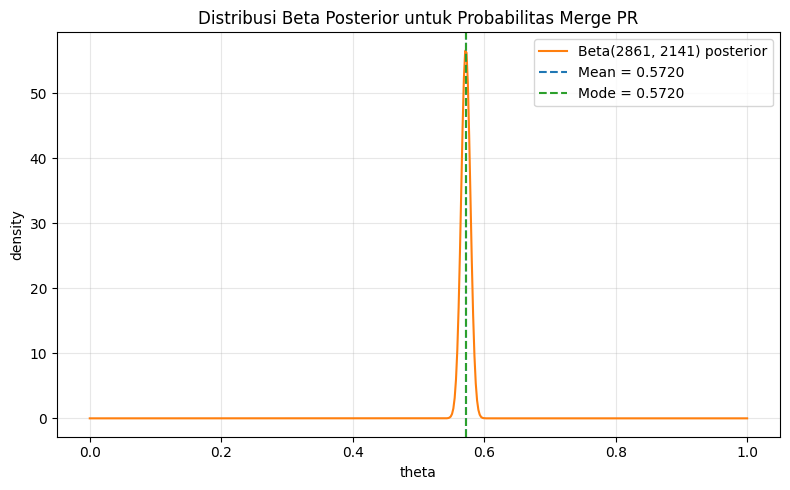

In [5]:
alpha = posterior['α']
beta = posterior['β']
mean_post = posterior['mean']
mode_post = posterior['mode']

theta_vals = np.linspace(1e-4, 1 - 1e-4, 500)
posterior_pdf = beta_dist.pdf(theta_vals, alpha, beta)

plt.figure(figsize=(8, 5))
plt.plot(theta_vals, posterior_pdf, color='tab:orange', label=f'Beta({alpha:.0f}, {beta:.0f}) posterior')
plt.axvline(mean_post, color='tab:blue', linestyle='--', label=f'Mean = {mean_post:.4f}')
if mode_post is not None:
    plt.axvline(mode_post, color='tab:green', linestyle='--', label=f'Mode = {mode_post:.4f}')
plt.title('Distribusi Beta Posterior untuk Probabilitas Merge PR')
plt.xlabel('theta')
plt.ylabel('density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Poisson MLE dan Log-Likelihood (jumlah issue per bulan)

In [6]:
issue_count_per_month = issues.groupby('year_month').size().values

lambda_hat = mle_poisson(issue_count_per_month)
ll_poisson_at_mle = log_likelihood_poisson(lambda_hat, issue_count_per_month)

print('Data count issue per bulan:', issue_count_per_month)
print(f'lambda_hat (MLE Poisson)  : {lambda_hat:.6f}')
print(f'log-likelihood di lambda_hat: {ll_poisson_at_mle:.4f}')

Data count issue per bulan: [ 40 163 139 116 144 156 215 133 107]
lambda_hat (MLE Poisson)  : 134.777778
log-likelihood di lambda_hat: -105.5611


## Ringkasan Hasil Estimasi

In [7]:
summary = pd.DataFrame([
    {
        'parameter': 'theta (Bernoulli merge rate)',
        'estimate': theta_hat,
        'log_likelihood_at_estimate': ll_bernoulli_at_mle,
    },
    {
        'parameter': 'lambda (Poisson issue count per month)',
        'estimate': lambda_hat,
        'log_likelihood_at_estimate': ll_poisson_at_mle,
    },
])

summary

,parameter,estimate,log_likelihood_at_estimate
0,theta (Bernoulli merge rate),0.572000,-3413.715241
1,lambda (Poisson issue count per month),134.777778,-105.561149


## Visualisasi Kurva Log-Likelihood

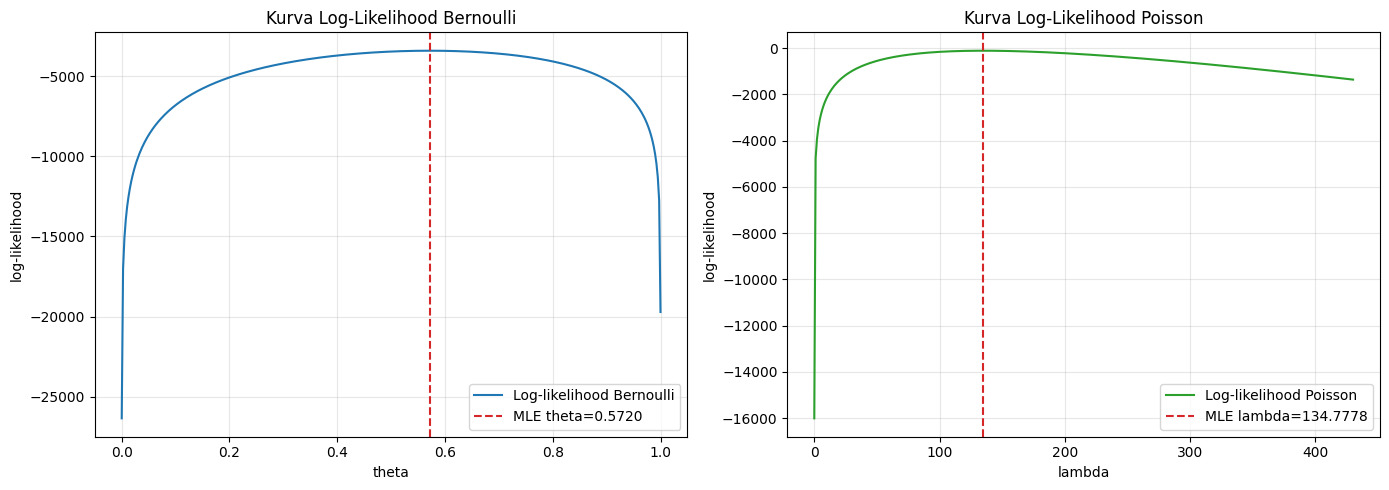

In [8]:
import matplotlib.pyplot as plt

if 'k' not in globals() or 'n' not in globals():
    bernoulli_data = prs['is_merged'].astype(int).values
    n = len(bernoulli_data)
    k = int(bernoulli_data.sum())

if 'theta_hat' not in globals():
    theta_hat = mle_bernoulli(prs['is_merged'].astype(int).values)

if 'issue_count_per_month' not in globals():
    issue_count_per_month = issues.groupby('year_month').size().values

if 'lambda_hat' not in globals():
    lambda_hat = mle_poisson(issue_count_per_month)

theta_grid = np.linspace(1e-4, 1 - 1e-4, 400)
ll_bernoulli_grid = [log_likelihood_bernoulli(t, k, n) for t in theta_grid]

lambda_max = max(float(issue_count_per_month.max()) * 2, 1.0)
lambda_grid = np.linspace(1e-4, lambda_max, 400)
ll_poisson_grid = [log_likelihood_poisson(lmbd, issue_count_per_month) for lmbd in lambda_grid]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(theta_grid, ll_bernoulli_grid, color='tab:blue', label='Log-likelihood Bernoulli')
axes[0].axvline(theta_hat, color='tab:red', linestyle='--', label=f'MLE theta={theta_hat:.4f}')
axes[0].set_title('Kurva Log-Likelihood Bernoulli')
axes[0].set_xlabel('theta')
axes[0].set_ylabel('log-likelihood')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(lambda_grid, ll_poisson_grid, color='tab:green', label='Log-likelihood Poisson')
axes[1].axvline(lambda_hat, color='tab:red', linestyle='--', label=f'MLE lambda={lambda_hat:.4f}')
axes[1].set_title('Kurva Log-Likelihood Poisson')
axes[1].set_xlabel('lambda')
axes[1].set_ylabel('log-likelihood')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()